**Przetwarzanie strumieni danych lista 5 Oliwia Borkowska**

**Zad. 1** Przygotuj w Pythonie kod, który wyznaczy widmo amplitudowe sygnału sinusoidalnego. 



In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from ipywidgets import interact, FloatSlider

def widmo_amplitudowe(f=2.0, fs=20.0, amplituda=1.0, faza=0.0, T=1.0):
    N = int(fs * T)
    t = np.linspace(0, T, N, endpoint=False)

    x = amplituda * np.sin(2 * np.pi * f * t + faza) # sygnal sinusoidalny
    
    X = fft(x) # FFT
    freqs = fftfreq(N, 1/fs)  
    
    amplitude_spectrum = 2.0/N * np.abs(X[:N//2]) # widmo amplitudowe, tylko części dodatnie
    positive_freqs = freqs[:N//2] # skalowanie
    
    plt.figure(figsize=(16, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(t, x, color='pink')
    plt.title('Sygnał w czasie')
    plt.xlabel('Czas [s]')
    plt.ylabel('Amplituda')

    plt.subplot(1, 2, 2)
    plt.plot(positive_freqs, amplitude_spectrum, color='magenta')
    plt.title('Widmo amplitudowe')
    plt.xlabel('Częstotliwość [Hz]')
    plt.ylabel('Amplituda')
    plt.grid(True)
    plt.xlim(0, 10)
    plt.tight_layout()

interact(
    widmo_amplitudowe,
    f=FloatSlider(value=2.0, min=0.1, max=10.0, step=0.1, description='f [Hz]'),
    fs=FloatSlider(value=20.0, min=2.0, max=100.0, step=1.0, description='fs [Hz]'),
    amplituda=FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='Amplituda'),
    faza=FloatSlider(value=0.0, min=0, max=2*np.pi, step=0.1, description='Faza [rad]'),
    T=FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='Czas trwania [s]')
)


interactive(children=(FloatSlider(value=2.0, description='f [Hz]', max=10.0, min=0.1), FloatSlider(value=20.0,…

<function __main__.widmo_amplitudowe(f=2.0, fs=20.0, amplituda=1.0, faza=0.0, T=1.0)>

**Zad. 2** Przygotuj w Pythonie kod, który wyznaczy widmo amplitudowe sygnału sinusoidalnego w skali decybelowej.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from ipywidgets import interact, FloatSlider

def widmo_amplitudowe_dB(f=2.0, fs=20.0, amplituda=1.0, faza=0.0, T=1.0, poziom_szumu=0.0):
    N = int(fs * T)
    t = np.linspace(0, T, N, endpoint=False)
    
    x = amplituda * np.sin(2 * np.pi * f * t + faza)
    
    if poziom_szumu > 0: # szum
        szum = np.random.normal(0, amplituda * poziom_szumu, N)
        x += szum
    
    X = fft(x) #FTT
    freqs = fftfreq(N, 1/fs)
    
    amplitude_spectrum = 2.0/N * np.abs(X[:N//2]) # widmo amplitudowe w dB
    amplitude_spectrum = np.maximum(amplitude_spectrum, 1e-10) # zapobiegnięcie log(0)
    dB_spectrum = 20 * np.log10(amplitude_spectrum)
    positive_freqs = freqs[:N//2]

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.plot(t, x, color='pink')
    plt.title('Sygnał w dziedzinie czasu')
    plt.xlabel('Czas [s]')
    plt.ylabel('Amplituda')
    
    plt.subplot(1, 3, 2)
    plt.plot(positive_freqs, amplitude_spectrum, color='magenta')
    plt.title('Widmo amplitudowe')
    plt.xlabel('Częstotliwość [Hz]')
    plt.ylabel('Amplituda')
    plt.grid(True)
    plt.xlim(0, 10)

    plt.subplot(1, 3, 3)
    plt.plot(positive_freqs, dB_spectrum, color='blue')
    plt.title('Widmo w skali dB')
    plt.xlabel('Częstotliwość [Hz]')
    plt.ylabel('Amplituda [dB]')
    plt.grid(True)
    plt.xlim(0, 10)
    plt.ylim(-80, 20)

    plt.tight_layout()
    plt.show()

interact(
    widmo_amplitudowe_dB,
    f=FloatSlider(value=2.0, min=0.1, max=10.0, step=0.1, description='f[Hz]'),
    fs=FloatSlider(value=20.0, min=2.0, max=100.0, step=1.0, description='fs [Hz]'),
    amplituda=FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='Amplituda'),
    faza=FloatSlider(value=0.0, min=0, max=2*np.pi, step=0.1, description='Faza [rad]'),
    T=FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='Czas [s]'),
    poziom_szumu=FloatSlider(value=0.0, min=0, max=100, step=1, description='Szum [%]')
)


interactive(children=(FloatSlider(value=2.0, description='f[Hz]', max=10.0, min=0.1), FloatSlider(value=20.0, …

<function __main__.widmo_amplitudowe_dB(f=2.0, fs=20.0, amplituda=1.0, faza=0.0, T=1.0, poziom_szumu=0.0)>

**Zad. 3** Przygotuj w Pythonie kod, który wyznaczy widmo amplitudowe sygnałów z zadania 1 na liście 1. 	

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq
from ipywidgets import interact, FloatSlider, Dropdown

def generuj_sygnal(
    nazwa, f=5.0, amp=1.0, T=1.0, fs=1000,
    faz=0.0, dc=0.5, f0=1, f1=50, 
    amp2=0.5, f2=10, faz2=0
):
    t = np.linspace(0, T, int(fs*T), endpoint=False)
    if nazwa == 'Sinus':
        sygnal = amp * np.sin(2*np.pi*f*t + faz)
    elif nazwa == 'Prostokątny':
        sygnal = amp * signal.square(2*np.pi*f*t + faz, duty=dc)
    elif nazwa == 'Piłokształtny':
        sygnal = amp * signal.sawtooth(2*np.pi*f*t + faz)
    elif nazwa == 'Świergotliwy':
        sygnal = amp * signal.chirp(t, f0=f0, f1=f1, t1=T, method='linear')
    elif nazwa == 'Superpozycja':
        sygnal = (amp * np.sin(2*np.pi*f*t + faz) + 
                  amp2 * np.cos(2*np.pi*f2*t + faz2))
    elif nazwa == 'Impuls':
        sygnal = amp * signal.unit_impulse(len(t), 'mid')
    else:
        sygnal = np.zeros_like(t)
    return t, sygnal

@interact(
    nazwa=Dropdown(options=['Sinus', 'Prostokątny', 'Piłokształtny', 
                           'Świergotliwy', 'Superpozycja', 'Impuls'],
                   value='Sinus', description='Typ sygnału:'),
    f=FloatSlider(min=1, max=50, step=0.5, value=5, description='f [Hz]'),
    amp=FloatSlider(min=0.1, max=5, value=1, description='Amplituda'),
    T=FloatSlider(min=0.1, max=5, value=1, step=0.1, description='Czas [s]'),
    fs=FloatSlider(min=100, max=10000, value=1000, step=100, description='Próbkowanie [Hz]'),
    faz=FloatSlider(min=0, max=2*np.pi, value=0, description='Faza [rad]'),
    dc=FloatSlider(min=0.1, max=0.9, value=0.5, description='Wypełnienie prostokąta'),
    f0=FloatSlider(min=1, max=50, value=1, description='F0 świergotu'),
    f1=FloatSlider(min=50, max=500, value=50, description='F1 świergotu'),
    amp2=FloatSlider(min=0.1, max=5, value=0.5, description='Amplituda 2'),
    f2=FloatSlider(min=1, max=50, value=10, description='f. 2'),
    faz2=FloatSlider(min=0, max=2*np.pi, value=0, description='Faza 2 [rad]')
)
def wyswietl_interaktywnie(nazwa, f, amp, T, fs, faz, dc, f0, f1, amp2, f2, faz2):
    t, sygnal = generuj_sygnal(nazwa, f, amp, T, fs, faz, dc, f0, f1, amp2, f2, faz2)
    N = len(sygnal)
    freqs = fftfreq(N, 1/fs)[:N//2]
    ampl = 2.0/N * np.abs(fft(sygnal)[:N//2])
    
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.plot(t, sygnal, color = 'skyblue')
    plt.title(f'{nazwa} - Czas')
    plt.xlabel('Czas [s]')
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(freqs, ampl)
    plt.title('Widmo amplitudowe')
    plt.xlabel('Częstotliwość [Hz]')
    plt.xlim(0, 100)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


interactive(children=(Dropdown(description='Typ sygnału:', options=('Sinus', 'Prostokątny', 'Piłokształtny', '…

**Zad. 4** Przygotuj w Pythonie kod, który wyznaczy widmo fazowe sygnału sinusoidalnego.

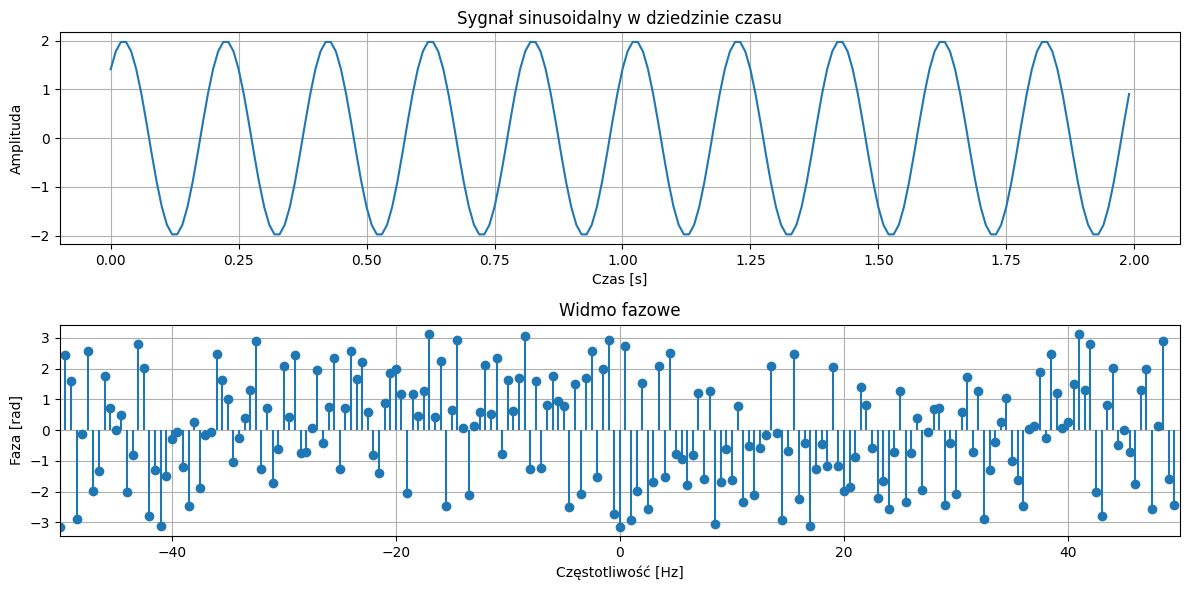

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

def widmo_fazowe(f=2.0, fs=100.0, amplituda=1.0, faza=0.0, T=1.0):

    N = int(fs * T) 
    t = np.linspace(0, T, N, endpoint=False)  
    x = amplituda * np.sin(2 * np.pi * f * t + faza)
    
    X = fft(x) # FFT
    freqs = fftfreq(N, 1/fs)  
    

    phase_spectrum = np.angle(X) 

    plt.figure(figsize=(12, 6))

    plt.subplot(2, 1, 1)
    plt.plot(t, x)
    plt.title('Sygnał sinusoidalny w dziedzinie czasu')
    plt.xlabel('Czas [s]')
    plt.ylabel('Amplituda')
    plt.grid(True)
    

    plt.subplot(2, 1, 2)
    plt.stem(freqs, phase_spectrum, basefmt=" ")
    plt.title('Widmo fazowe')
    plt.xlabel('Częstotliwość [Hz]')
    plt.ylabel('Faza [rad]')
    plt.xlim(-fs/2, fs/2) 
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

widmo_fazowe(f=5, fs=100, amplituda=2, faza=np.pi/4, T=2)


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from ipywidgets import interact, FloatSlider

def widmo_fazowe(f=2.0, fs=100.0, amplituda=1.0, faza=0.0, T=1.0):

    N = int(fs * T) 
    t = np.linspace(0, T, N, endpoint=False)  
    x = amplituda * np.sin(2 * np.pi * f * t + faza)
    
    X = fft(x) # FFT
    freqs = fftfreq(N, 1/fs)  

    phase_spectrum = np.angle(X) 

    plt.figure(figsize=(12, 6))

    plt.subplot(2, 1, 1)
    plt.plot(t, x)
    plt.title('Sygnał sinusoidalny w dziedzinie czasu')
    plt.xlabel('Czas [s]')
    plt.ylabel('Amplituda')
    plt.grid(True)

    plt.subplot(2, 1, 2)
    plt.stem(freqs, phase_spectrum, basefmt=" ")
    plt.title('Widmo fazowe')
    plt.xlabel('Częstotliwość [Hz]')
    plt.ylabel('Faza [rad]')
    plt.xlim(-fs/2, fs/2)
    plt.ylim(-np.pi, np.pi)
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

interact(
    widmo_fazowe,
    f=FloatSlider(value=5, min=0.1, max=50, step=0.1, description='Częstotliwość [Hz]'),
    fs=FloatSlider(value=100, min=10, max=1000, step=10, description='Próbkowanie [Hz]'),
    amplituda=FloatSlider(value=2, min=0.1, max=5, step=0.1, description='Amplituda'),
    faza=FloatSlider(value=0, min=0, max=2*np.pi, step=0.1, description='Faza [rad]'),
    T=FloatSlider(value=1, min=0.1, max=5, step=0.1, description='Czas trwania [s]')
)


interactive(children=(FloatSlider(value=5.0, description='Częstotliwość [Hz]', max=50.0, min=0.1), FloatSlider…

<function __main__.widmo_fazowe(f=2.0, fs=100.0, amplituda=1.0, faza=0.0, T=1.0)>

**Zad. 5** Przygotuj w Pythonie kod, który wyznaczy obwiednie dla sygnału świergotliwego (chirp signal)

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import chirp, hilbert
from ipywidgets import interact, FloatSlider

def obwiednia_chirp(f0=20.0, f1=100.0, T=1.0, fs=1000):

    t = np.linspace(0, T, int(fs*T), endpoint=False)
    
    sygnal = chirp(t, f0=f0, f1=f1, t1=T, method='linear')
    
    analityczny = hilbert(sygnal)
    obwiednia = np.abs(analityczny)

    plt.figure(figsize=(12, 6))
    plt.plot(t, sygnal, label='Sygnał świergotliwy', alpha=0.7)
    plt.plot(t, obwiednia, 'r', linewidth=2, label='Obwiednia')
    plt.title('Sygnał świergotliwy z obwiednią')
    plt.xlabel('Czas [s]')
    plt.ylabel('Amplituda')
    plt.grid(True)
    plt.legend()
    plt.show()

interact(
    obwiednia_chirp,
    f0=FloatSlider(value=20, min=1, max=200, step=1, description='Częstotliwość początkowa [Hz]'),
    f1=FloatSlider(value=100, min=1, max=500, step=1, description='Częstotliwość końcowa [Hz]'),
    T=FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='Czas trwania [s]'),
    fs=FloatSlider(value=1000, min=100, max=10000, step=100, description='Próbkowanie [Hz]')
)


interactive(children=(FloatSlider(value=20.0, description='Częstotliwość początkowa [Hz]', max=200.0, min=1.0,…

<function __main__.obwiednia_chirp(f0=20.0, f1=100.0, T=1.0, fs=1000)>

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import chirp, hilbert
from ipywidgets import interact, FloatSlider

def obwiednia(f0=20.0, f1=100.0, T=1.0, fs=1000, mod_amp=0.5, mod_freq=5.0):

    t = np.linspace(0, T, int(fs*T), endpoint=False)
    
    amplituda = 1.0 + mod_amp * np.sin(2*np.pi*mod_freq*t)
    
    sygnal = amplituda * chirp(t, f0=f0, f1=f1, t1=T, method='linear')
    
    analityczny = hilbert(sygnal)
    obwiednia = np.abs(analityczny)
    
    plt.figure(figsize=(12, 6))
    plt.plot(t, sygnal, label='Sygnał świergotliwy', alpha=0.7)
    plt.plot(t, obwiednia, 'r', linewidth=2, label='Obwiednia')
    plt.title('Sygnał z obwiednią')
    plt.xlabel('Czas [s]')
    plt.ylabel('Amplituda')
    plt.grid(True)
    plt.legend()
    plt.show()

interact(
    obwiednia,
    f0=FloatSlider(value=20, min=1, max=200, step=1, description='Częstotliwość początkowa [Hz]'),
    f1=FloatSlider(value=100, min=1, max=500, step=1, description='Częstotliwość końcowa [Hz]'),
    T=FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='Czas trwania [s]'),
    fs=FloatSlider(value=1000, min=100, max=10000, step=100, description='Próbkowanie [Hz]'),
    mod_amp=FloatSlider(value=0.5, min=0.0, max=1.0, step=0.1, description='Głębokość modulacji'),
    mod_freq=FloatSlider(value=5.0, min=0.1, max=20.0, step=0.1, description='Częstotliwość modulacji [Hz]')
)


interactive(children=(FloatSlider(value=20.0, description='Częstotliwość początkowa [Hz]', max=200.0, min=1.0,…

<function __main__.obwiednia(f0=20.0, f1=100.0, T=1.0, fs=1000, mod_amp=0.5, mod_freq=5.0)>

In [11]:
# robocze 

import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq
from ipywidgets import interact, FloatSlider

def widmo_fazowe(f=2.0, fs=50.0, amplituda=1.0, faza=0.0, T=1.0):
    N = int(fs * T)  # liczba próbek
    t = np.linspace(0, T, N, endpoint=False)  # wektor czasu

    # Sygnał sinusoidalny
    x = amplituda * np.sin(2 * np.pi * f * t + faza)

    # FFT tylko dla częstotliwości dodatnich
    X = rfft(x)
    freqs = rfftfreq(N, 1/fs)

    # Widmo fazowe: argument zespolonego widma, rozwinięty bez skoków 2π
    phase_spectrum = np.unwrap(np.angle(X))

    # Wykres
    plt.figure(figsize=(12, 5))
    plt.plot(freqs, phase_spectrum, marker='o')
    plt.title('Widmo fazowe sygnału sinusoidalnego')
    plt.xlabel('Częstotliwość [Hz]')
    plt.ylabel('Faza [rad]')
    plt.grid(True)
    plt.xlim(0, fs/2)
    plt.ylim(-np.pi, np.pi)
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.show()

# Interaktywne suwaki
interact(
    widmo_fazowe,
    f=FloatSlider(value=2.0, min=0.1, max=20.0, step=0.1, description='Częstotliwość [Hz]'),
    fs=FloatSlider(value=50.0, min=10.0, max=200.0, step=1.0, description='Próbkowanie [Hz]'),
    amplituda=FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='Amplituda'),
    faza=FloatSlider(value=0.0, min=0, max=2*np.pi, step=0.1, description='Faza [rad]'),
    T=FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='Czas trwania [s]')
)




import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from ipywidgets import interact, FloatSlider

def widmo_fazowe(f=2.0, fs=20.0, amplituda=1.0, faza=0.0, T=1.0):
    N = int(fs * T)
    t = np.linspace(0, T, N, endpoint=False)
    
    # Sygnał sinusoidalny
    x = amplituda * np.sin(2 * np.pi * f * t + faza)
    
    # FFT i częstotliwości
    X = fft(x)
    freqs = fftfreq(N, 1/fs)
    
    # Widmo fazowe
    phase_spectrum = np.angle(X[:N//2])
    positive_freqs = freqs[:N//2]

    # Rysowanie wykresu fazy
    plt.figure(figsize=(12, 5))
    plt.plot(positive_freqs, phase_spectrum, marker='o')
    plt.title('Widmo fazowe sygnału sinusoidalnego')
    plt.xlabel('Częstotliwość [Hz]')
    plt.ylabel('Faza [rad]')
    plt.grid(True)
    plt.xlim(0, 100)
    plt.ylim(-np.pi, np.pi)  # zakres -π do π
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.show()

# Interaktywny interfejs
interact(
    widmo_fazowe,
    f=FloatSlider(value=2.0, min=0.1, max=10.0, step=0.1, description='Częstotliwość [Hz]'),
    fs=FloatSlider(value=20.0, min=2.0, max=100.0, step=1.0, description='Częstotliwość próbkowania [Hz]'),
    amplituda=FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='Amplituda'),
    faza=FloatSlider(value=0.0, min=0, max=2*np.pi, step=0.1, description='Faza [rad]'),
    T=FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='Czas trwania [s]')
)